In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import plotly.offline as py
import plotly.graph_objs as go
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

py.init_notebook_mode(connected=True)


from dataset import TimeSeriesDataset
from tsne import cluster_plot


In [3]:
dataset = TimeSeriesDataset()

('Dataset Statistics:\n', "All:('Dataset Lenght:362', 'Label_mean:0.6546961325966851')\n", "Train:('Dataset Lenght:271', 'Label_mean:0.6826568265682657')\n", "Test :('Dataset Lenght:91', 'Label_mean:0.5714285714285714')\n")


In [4]:
dataset.FEATURES

['var', 'skew', 'kurtosis', 'rms', 'crest_factor']

In [5]:
def standardize(x):
    return (x-np.mean(x))/np.std(x)

for key in dataset.FEATURES:
    dataset.dataframe[key] = standardize(dataset.dataframe[key].values)

In [6]:
fig = go.Figure(data=[go.Scatter(y=dataset.dataframe.loc[:, key],
                                name=key,
                                hoverinfo='text',
                                hovertext=dataset.dataframe.loc[:, 'label']) for key in dataset.FEATURES])
fig.show()

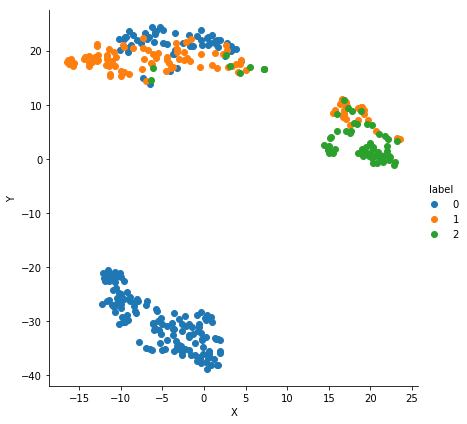

In [7]:

X = dataset.dataframe.loc[:, dataset.FEATURES]
y = dataset.dataframe.loc[:, 'label']
cluster_plot(X, y, model=TSNE(n_components=2, random_state=0, perplexity=30, learning_rate=200, n_iter=1000),
              backend='seaborn')

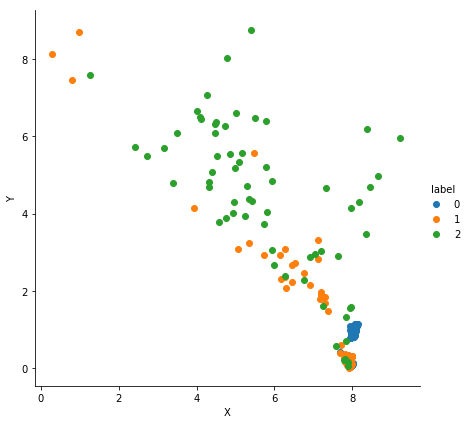

In [12]:
cluster_plot(X, y, model=KMeans(n_clusters=20, random_state=0),
              backend='seaborn')